<a href="https://colab.research.google.com/github/SampMark/Deep-Learning/blob/main/Convolutional_Neural_Networks_with_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Redes Neurais Convolucionais com o MNIST**

Este laboratório tem por objetivo a criação e copilação, treinamento e avaliação de um modelo de Redes Neurais Convolucionais com "camadas de convolução de transposição" para tarefa de reconhecimento de dígitos (reconhecimento de imagens) usando o dataset do MNIST do TensorFlow.

## **Sobre o MNIST Dataset**

O **MNIST Dataset** é um dos conjuntos de dados mais icônicos e amplamente utilizados no campo de aprendizado de máquina e visão computacional. Tem por objetivo servir como **benchmark** para avaliar algoritmos de aprendizado de máquina, especialmente em tarefas de **reconhecimento de padrões** e **classificação de imagens**.

É composto por **70.000 imagens de dígitos manuscritos (0 a 9)**, em escala de cinza, padronizadas em **28x28 pixels**, dividas em:  
  - **60.000 imagens** para treinamento.  
  - **10.000 imagens** para teste/validação.

### **Algumas Aplicações Práticas**

- **Educação e Pesquisa**: é o dataset introdutório mais comum para ensinar **deep learning**, devido à sua simplicidade e eficácia. O MNIST é uma **ferramenta pedagógica essencial** para introduzir CNNs, pois permite explorar desde operações básicas (convoluções, _pooling_) até técnicas avançadas (regularização, visualização de _features_) em um "ambiente controlado".

- **Reconhecimento de Dígitos**: serve como base para sistemas de reconhecimento de escrita manual.  

- **Teste de Algoritmos**: é comumente utilizado para validar redes neurais convolucionais (ex.: CNNs) e técnicas como *transfer learning*.

### **Características Técnicas**
- **Formato das Imagens**: cada imagem é uma matriz **28x28 pixels** em escala de cinza (valores de pixel entre 0 e 255).  
  - As imagens foram normalizadas (centralizadas e redimensionadas) para garantir consistência.  

- **Distribuição das Classes**: contém **10 classes** (dígitos de 0 a 9).  
  - Possui distribuição balanceada: ~6.000 exemplos por classe no treinamento, evitando viés em métricas como acurácia.  

- **Pré-processamento**: alguns trabalhos aplicam técnicas como **redução de contraste** ou **normalização** (ex.: valores escalonados para [0, 1]) para melhorar o desempenho de modelos.  

O MNIST permanece como um **marco histórico** na área de _machine learning_, tendo sido superado por _datasets_ mais complexos, tais como, CIFAR-10 e o ImageNet, mas sua simplicidade o torna ideal para estudos introdutórios.



In [ ]:
!pip install tensorflow matplotlib

In [ ]:
# @title Importando bibliotecas necessárias...
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# =============================================================================
# @title Arquitetura do Modelo (Autoencoder Simples)
# =============================================================================

# Entrada: imagens com formato 28x28 e 1 canal (escala de cinza)
input_layer = Input(shape=(28, 28, 1), name="input")

# Camada convolucional:
# - 32 filtros com kernel 3x3
# - 'padding=same' para manter a dimensão da imagem
# - 'activation=relu' para introduzir não-linearidade
conv_layer = Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    padding='same',
    name="conv1")(input_layer)

# Camada de normalização para estabilizar as ativações
bn_conv = BatchNormalization(name="bn_conv")(conv_layer)

# Camada de Dropout para reduzir o overfitting (descarta 20% dos neurônios durante o treino)
drop_conv = Dropout(rate=0.2, name="drop_conv")(bn_conv)

# Camada de transposição convolucional:
# - Reconstrói a imagem a partir das características extraídas
# - 1 filtro para manter o mesmo número de canais (escala de cinza)
# - 'activation=sigmoid' para normalizar as saídas entre 0 e 1
transpose_conv_layer = Conv2DTranspose(
    filters=1,
    kernel_size=(3, 3),
    activation='sigmoid',
    padding='same',
    name="deconv")(drop_conv)

# =============================================================================
# Criação do modelo
# =============================================================================
# Definições de entrada e saída
model = Model(inputs=input_layer, outputs=transpose_conv_layer, name="AutoencoderSimples")

# =============================================================================
# Compilação do Modelo
# =============================================================================

# Utiliza o otimizador Adam e a perda de erro quadrático médio (mean squared error)
model.compile(optimizer='adam', loss='mean_squared_error')

# Exibe um resumo da arquitetura do modelo
model.summary()

Model: "AutoencoderSimples"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_conv (BatchNormalization)         │ (None, 28, 28, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_conv (Dropout)                  │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deconv (Conv2DTranspose)             │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# =============================================================================
# @title Preparação dos Dados de Treinamento
# =============================================================================

# Gerando dados aleatórios para simular imagens (em um cenário real, utilize dados reais)
X_train = np.random.rand(1000, 28, 28, 1)

# Para um autoencoder, os rótulos são as próprias imagens de entrada
y_train = X_train

print(X_train.shape)

(1000, 28, 28, 1)


In [ ]:
# =============================================================================
# @title Configuração de _Callbacks_ para Monitorar o Treinamento
# =============================================================================

# EarlyStopping: Interrompe o treinamento se a perda de validação não melhorar após 3 épocas
# ModelCheckpoint: Salva o modelo com a melhor perda de validação
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, verbose=1),
    ModelCheckpoint('autoencoder_melhor.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# =============================================================================
# Treinamento do Modelo
# =============================================================================

# Treina o modelo por 10 épocas com divisão de 20% dos dados para validação
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1145
Epoch 1: val_loss improved from inf to 0.06803, saving model to autoencoder_melhor.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.1130 - val_loss: 0.0680
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0151
Epoch 2: val_loss improved from 0.06803 to 0.06089, saving model to autoencoder_melhor.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0151 - val_loss: 0.0609
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0094
Epoch 3: val_loss improved from 0.06089 to 0.05930, saving model to autoencoder_melhor.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0094 - val_loss: 0.0593
Epoch 4/10
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0079
Epoch 4: val_loss improved from 0.05930 to 0.05687, saving model to autoencoder_melhor.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0079 - val_loss: 0.0569
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0070
Epoch 

In [ ]:
# Geração de dados de teste aleatórios
X_test = np.random.rand(200, 28, 28, 1)
y_test = X_test

# Cálculo da perda do modelo em dados de teste
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0375
Test loss: 0.03745461627840996


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


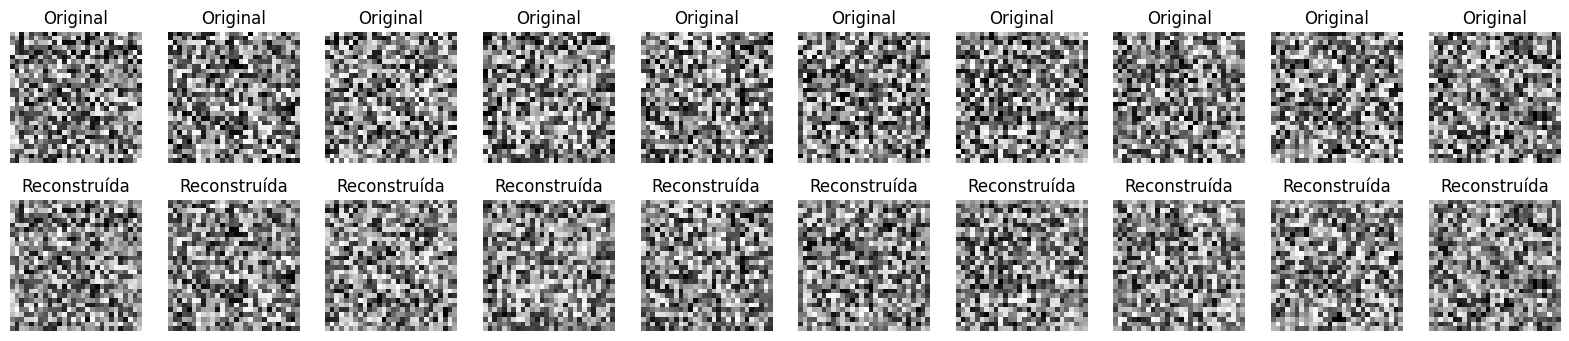

In [ ]:
# Previsão com base nos dados de teste
y_pred = model.predict(X_test)
n = 10

# Visualização das imagens originais e as reconstruídas lado a lado para comparação
plt.figure(figsize=(20, 4))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(y_pred[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruída")
    plt.axis('off')

plt.show()

## **Aperfeiçoamento da arquitetura autoencoder para o conjunto de dados MNIST**

A seguir apliquei as seguintes melhorias:

* **Estrutura do Modelo**: melhor organização do fluxo de construção do modelo de autoencoder convolucional $(input → encoder → bottleneck → decoder → output)$.
* Melhor definição do modelo com `Model(inputs, outputs)` antes de compilar e treinar.
  * Inclusão de camadas de `BatchNormalization`, após as convoluções para **estabilizar o treinamento**.
  * Uso de `MaxPooling2D` no **encoder** e `Conv2DTranspose` no **decoder** para recuperar as dimensões originais.
  * Inclusão de _callbacks_ (`EarlyStopping` e `ModelCheckpoint`) para **interromper o treinamento** quando não houver melhora na validação.
* **Visualização das reconstruções** das imagens do conjunto de teste em comparação com as originais.

In [ ]:
# =============================================================================
# @title Carregamento e Preprocessamento dos Dados (MNIST)
# =============================================================================
# Carrega o conjunto de dados MNIST
(X_train, _), (X_test, _) = mnist.load_data()

# Normaliza os dados para o intervalo [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Expande a dimensão para representar o canal (imagens em escala de cinza)
X_train = np.expand_dims(X_train, axis=-1)
X_test  = np.expand_dims(X_test, axis=-1)

# Em autoencoders, os rótulos são as próprias imagens de entrada
y_train = X_train
y_test  = X_test

print(X_train.shape)

(60000, 28, 28, 1)


In [ ]:
# =============================================================================
# @title Definição da Arquitetura do Autoencoder
# =============================================================================
# Definindo a camada de entrada
input_layer = Input(shape=(28, 28, 1), name="input")

# ----- Encoder -----
# Primeira camada convolucional: saída 28x28x32
x = Conv2D(32, (3, 3), activation='relu', padding='same', name="enc_conv1")(input_layer)
x = BatchNormalization(name="enc_bn1")(x)
# Redução para 14x14
x = MaxPooling2D((2, 2), padding='same', name="enc_pool1")(x)

# Segunda camada convolucional: saída 14x14x64
x = Conv2D(64, (3, 3), activation='relu', padding='same', name="enc_conv2")(x)
x = BatchNormalization(name="enc_bn2")(x)
# Redução para 7x7
x = MaxPooling2D((2, 2), padding='same', name="enc_pool2")(x)

# ----- Bottleneck -----
# Neste exemplo, mantemos a representação 7x7x64. Poderia-se adicionar camadas densas se necessário.

# ----- Decoder -----
# Primeira camada de decodificação: reconstrói para 14x14x64
x = Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same', name="dec_deconv1")(x)
x = BatchNormalization(name="dec_bn1")(x)
# Segunda camada de decodificação: reconstrói para 28x28x32
x = Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same', name="dec_deconv2")(x)
x = BatchNormalization(name="dec_bn2")(x)
# Camada final para gerar a imagem reconstruída (28x28x1) com valores entre 0 e 1
output_layer = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="output")(x)

# Criação do modelo
model = Model(inputs=input_layer, outputs=output_layer, name="Autoencoder")
model.compile(optimizer='adam', loss='binary_crossentropy')  # 'binary_crossentropy' é adequado para dados normalizados em [0,1]
model.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_conv1 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_bn1 (BatchNormalization)         │ (None, 28, 28, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_pool1 (MaxPooling2D)             │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_conv2 (Conv2D)                   │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_bn2 (BatchNormalization)         │ (None, 14, 14, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_pool2 (MaxPooling2D)             │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_deconv1 (Conv2DTranspose)        │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_bn1 (BatchNormalization)         │ (None, 14, 14, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_deconv2 (Conv2DTranspose)        │ (None, 28, 28, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_bn2 (BatchNormalization)         │ (None, 28, 28, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Conv2D)                      │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# =============================================================================
# Configuração dos Callbacks
# =============================================================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, verbose=1),
    ModelCheckpoint('autoencoder.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# =============================================================================
# Treinamento do Modelo
# =============================================================================
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.1621
Epoch 1: val_loss improved from inf to 0.06849, saving model to autoencoder.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 182s 238ms/step - loss: 0.1620 - val_loss: 0.0685
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - loss: 0.0662
Epoch 2: val_loss improved from 0.06849 to 0.06486, saving model to autoencoder.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 184s 245ms/step - loss: 0.0662 - val_loss: 0.0649
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 0.0646
Epoch 3: val_loss improved from 0.06486 to 0.06418, saving model to autoencoder.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 205s 249ms/step - loss: 0.0646 - val_loss: 0.0642
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 0.0636
Epoch 4: val_loss improved from 0.06418 to 0.06339, saving model to autoencoder.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 199s 265ms/step - loss: 0.0636 - val_loss: 0.0634
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.0628

In [ ]:
# =============================================================================
# @title Avaliação do Modelo
# =============================================================================
loss = model.evaluate(X_test, y_test)
print(f"Loss de teste: {loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.0597
Loss de teste: 0.06035109981894493


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


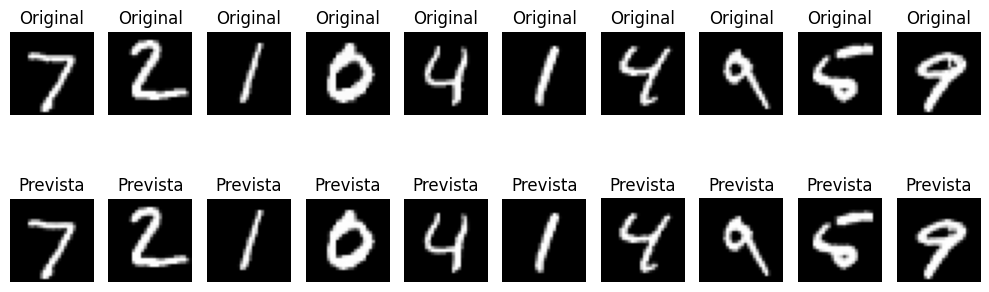

In [ ]:
# =============================================================================
# @title Visualização das Reconstruções
# =============================================================================
n = 10  # Número de imagens para visualizar
plt.figure(figsize=(10, 4))
for i in range(n):
    # Exibe a imagem original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Exibe a imagem reconstruída
    ax = plt.subplot(2, n, i + 1 + n)
    recon = model.predict(X_test[i:i+1])
    plt.imshow(recon.reshape(28, 28), cmap='gray')
    plt.title("Prevista")
    plt.axis('off')
plt.tight_layout()
plt.show()